In [12]:
# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set standard plotting style
plt.style.use('ggplot')
sns.set_palette("muted")

# ---------------------------------------------------------
# Define input pairs here. 
# ---------------------------------------------------------
input_pairs = [
    # {
    #     "model_name": "DSV4_TFOld",
    #     "result_file": "result/iacgod/NeoDPIaCEval_TF_DeepseekV4Flash_security_runs.csv",
    #     "coverage_file": "result/iacgod/Coverage_DSV4_TF_Sec.csv"
    # },
    # {
    #     "model_name": "DSV4_TFEval",
    #     "result_file": "result/iacgod/TFEval_DeepseekV4Flash_security_runs.csv",
    #     "coverage_file": "result/iacgod/Coverage_DSV4_TFEval_Sec.csv"
    # },
    {
        "model_name": "DSV4_TFEvalV2",
        "result_file": "result/iacgod/TFEvalV2_DeepseekV4Flash_security_runs.csv",
        "coverage_file": "result/iacgod/Coverage_DSV4_TFEvalV2_Sec.csv"
    }
]

In [13]:
merged_dataframes = {}

for pair in input_pairs:
    model = pair["model_name"]
    res_df = pd.read_csv(pair["result_file"])
    cov_df = pd.read_csv(pair["coverage_file"])

    # Merge based on ground_truth_path (or row_number for legacy CFN)
    merge_key = "ground_truth_path" if "ground_truth_path" in cov_df.columns else "row_number"
    
    cols_to_use = cov_df.columns.difference(res_df.columns).tolist() + [merge_key]
    merged_df = pd.merge(res_df, cov_df[cols_to_use], on=merge_key, how="left")
    merged_dataframes[model] = merged_df

    print(f"✅ Successfully merged {len(merged_df)} rows for {model} (Key: {merge_key}).")

✅ Successfully merged 150 rows for DSV4_TFEvalV2 (Key: ground_truth_path).


📊 Overall Pass Rates:
  -> DSV4_TFEvalV2: 144/150 (96.0%)


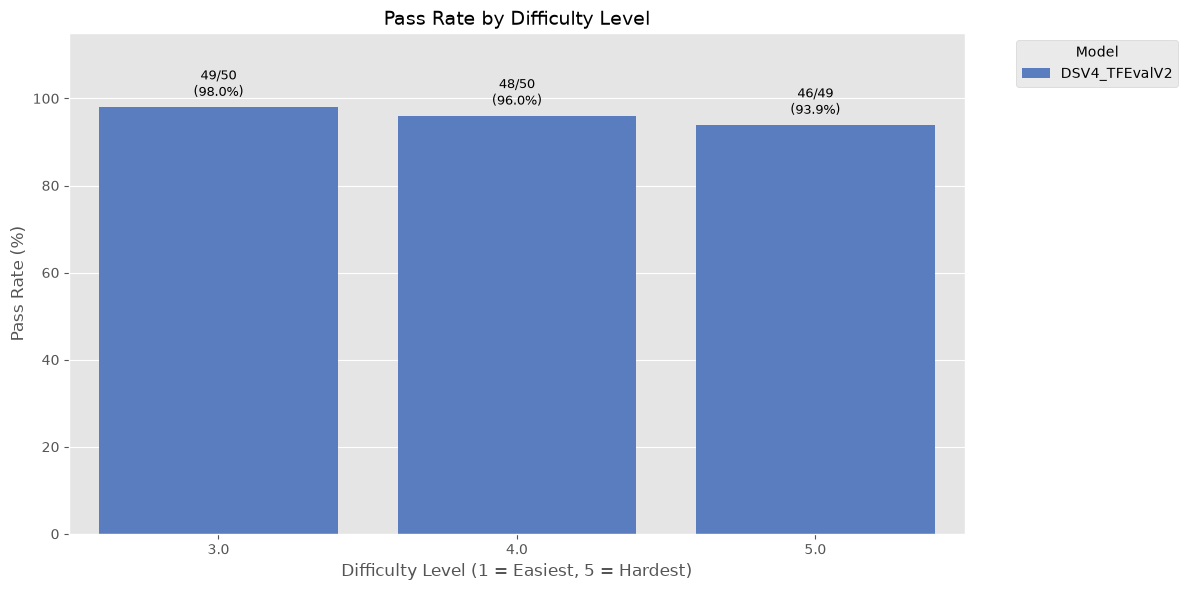

In [14]:
# %%
# ── 1. Pass Rate by Difficulty ────────────────────────────────────────────────
difficulty_stats = []

print("📊 Overall Pass Rates:")
for model_name, df in merged_dataframes.items():
    diff_col = 'difficulty_level' if 'difficulty_level' in df.columns else 'difficulty'
    val_col = 'final_validation_passed' if 'final_validation_passed' in df.columns else ('deploy_pass' if 'deploy_pass' in df.columns else None)

    if diff_col in df.columns and val_col in df.columns:
        # Calculate overall pass rate
        total_passed = int(df[val_col].sum())
        total_scenarios = len(df)
        overall_rate = (total_passed / total_scenarios * 100) if total_scenarios > 0 else 0
        print(f"  -> {model_name}: {total_passed}/{total_scenarios} ({overall_rate:.1f}%)")

        # Calculate pass rate per difficulty
        grouped = df.groupby(diff_col)[val_col].agg(['sum', 'count', 'mean'])
        
        for diff, row in grouped.iterrows():
            passed_cnt = int(row['sum'])
            total_cnt = int(row['count'])
            rate = row['mean'] * 100
            
            difficulty_stats.append({
                'Model': model_name,
                'Difficulty Level': diff,
                'Passed': passed_cnt,
                'Total': total_cnt,
                'Pass Rate (%)': rate
            })

if difficulty_stats:
    diff_df = pd.DataFrame(difficulty_stats)
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=diff_df, x='Difficulty Level', y='Pass Rate (%)', hue='Model')
    
    plt.title('Pass Rate by Difficulty Level', fontsize=14)
    plt.ylim(0, 115)  # Increased ylim to accommodate the text labels
    plt.xlabel('Difficulty Level (1 = Easiest, 5 = Hardest)')
    plt.ylabel('Pass Rate (%)')
    
    # Move legend outside to prevent overlap with text
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add labels to the top of each bar
    for i, container in enumerate(ax.containers):
        # Each container represents a hue (Model)
        model_name = ax.get_legend().get_texts()[i].get_text()
        
        for j, p in enumerate(container):
            height = p.get_height()
            if pd.isna(height) or (height == 0 and p.get_y() == 0):
                continue  # Skip empty bars
                
            # The x-tick label corresponds to the difficulty level
            diff_level = ax.get_xticklabels()[j].get_text()
            
            # Retrieve the exact counts from our dataframe
            row = diff_df[(diff_df['Model'] == model_name) & (diff_df['Difficulty Level'].astype(str) == diff_level)]
            
            if not row.empty:
                passed = row['Passed'].values[0]
                total = row['Total'].values[0]
                rate = row['Pass Rate (%)'].values[0]
                
                label_text = f"{passed}/{total}\n({rate:.1f}%)"
                
                # Annotate the bar
                ax.annotate(label_text, 
                            (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='bottom', 
                            xytext=(0, 5), textcoords='offset points',
                            fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Could not find difficulty or validation columns to plot Pass Rate.")

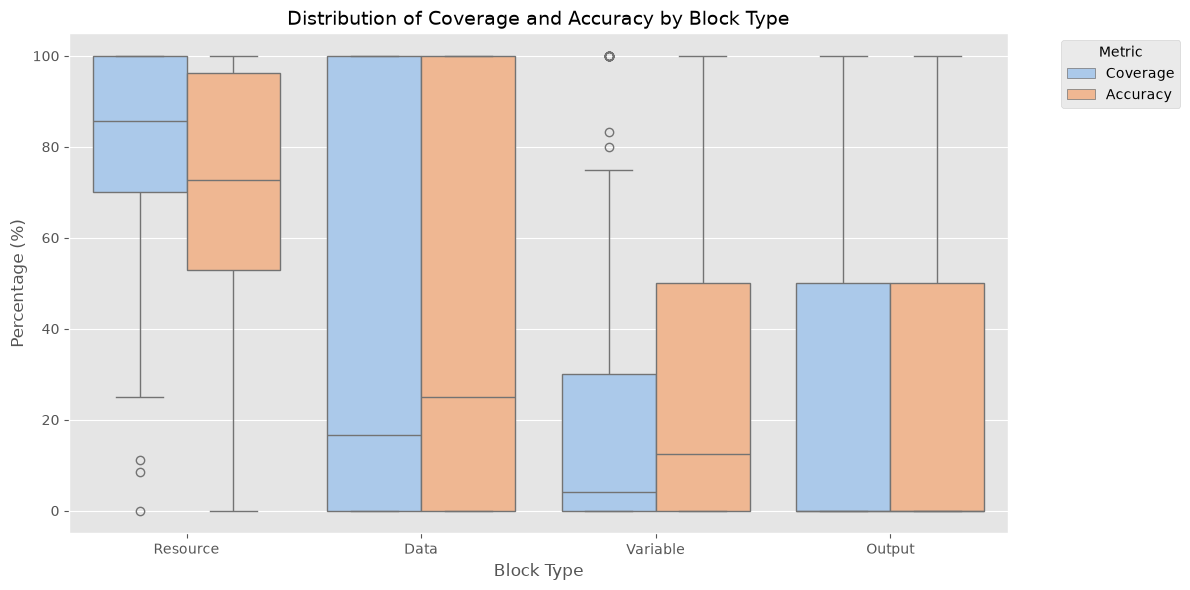

In [15]:
# ── 2. Coverage & Accuracy Distributions by Block Type (Boxplots) ─────────────
box_data = []
block_types = ['resource', 'data', 'variable', 'output']

for model_name, df in merged_dataframes.items():
    # Legacy CFN Support
    if 'coverage_pct' in df.columns:
        for _, row in df.dropna(subset=['coverage_pct', 'accuracy_pct']).iterrows():
            box_data.append({'Model': model_name, 'Block Type': 'Resource', 'Metric': 'Coverage', 'Percentage': row['coverage_pct']})
            box_data.append({'Model': model_name, 'Block Type': 'Resource', 'Metric': 'Accuracy', 'Percentage': row['accuracy_pct']})
    else:
        # New TF Block Types
        for btype in block_types:
            cov_col, acc_col = f'{btype}_cov_pct', f'{btype}_acc_pct'
            if cov_col in df.columns and acc_col in df.columns:
                for _, row in df.dropna(subset=[cov_col, acc_col]).iterrows():
                    box_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Metric': 'Coverage', 'Percentage': row[cov_col]})
                    box_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Metric': 'Accuracy', 'Percentage': row[acc_col]})

if box_data:
    box_df = pd.DataFrame(box_data)
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=box_df, x='Block Type', y='Percentage', hue='Metric', palette='pastel')
    plt.title('Distribution of Coverage and Accuracy by Block Type', fontsize=14)
    plt.ylabel('Percentage (%)')
    plt.ylim(-5, 105)
    plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

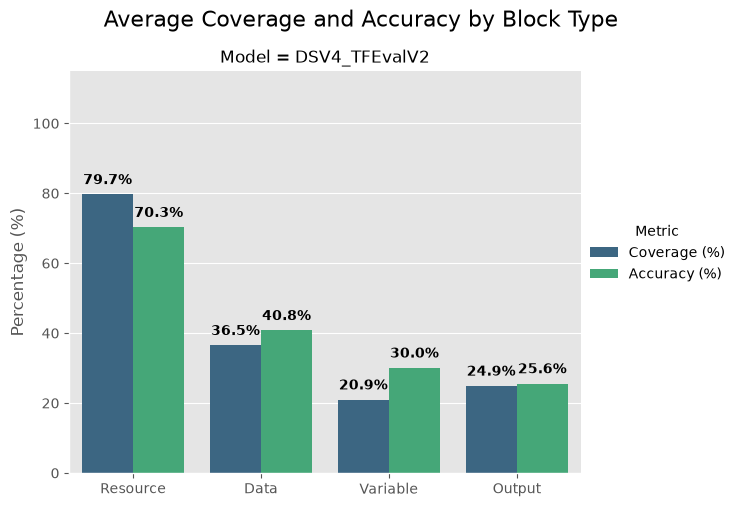

In [16]:
# ── 3. Average Coverage and Accuracy Bar Chart (By Block Type) ────────────────
avg_metrics_data = []

for model_name, df in merged_dataframes.items():
    if 'coverage_pct' in df.columns:
        avg_metrics_data.append({'Model': model_name, 'Block Type': 'Resource', 'Metric': 'Coverage (%)', 'Value': df['coverage_pct'].mean()})
        avg_metrics_data.append({'Model': model_name, 'Block Type': 'Resource', 'Metric': 'Accuracy (%)', 'Value': df['accuracy_pct'].mean()})
    else:
        for btype in block_types:
            cov_col, acc_col = f'{btype}_cov_pct', f'{btype}_acc_pct'
            if cov_col in df.columns and acc_col in df.columns:
                avg_metrics_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Metric': 'Coverage (%)', 'Value': df[cov_col].mean()})
                avg_metrics_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Metric': 'Accuracy (%)', 'Value': df[acc_col].mean()})

if avg_metrics_data:
    avg_df = pd.DataFrame(avg_metrics_data)
    
    # Use catplot to handle single or multiple models elegantly
    g = sns.catplot(
        data=avg_df, kind="bar",
        x="Block Type", y="Value", hue="Metric", col="Model",
        palette="viridis", height=5, aspect=1.2
    )
    
    g.set_axis_labels("", "Percentage (%)")
    g.set(ylim=(0, 115))
    g.fig.suptitle('Average Coverage and Accuracy by Block Type', fontsize=16, y=1.05)

    # Add data labels to bars
    for ax in g.axes.flat:
        for p in ax.patches:
            height = p.get_height()
            if pd.notna(height) and height > 0:
                ax.text(p.get_x() + p.get_width() / 2., height + 2, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
                
    plt.show()

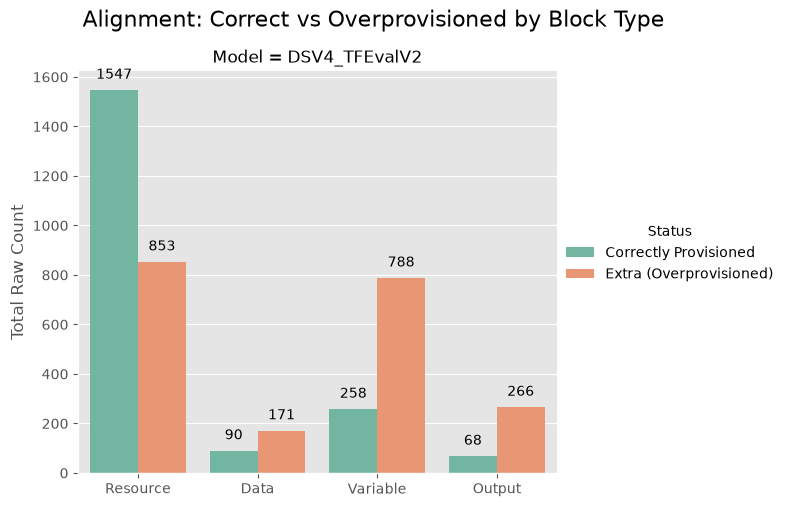

In [17]:
# ── 4. Resource Alignment: Correct vs Overprovisioned (By Block Type) ─────────
overprovisioning_data = []

for model_name, df in merged_dataframes.items():
    if 'correct_resources' in df.columns:
        overprovisioning_data.append({'Model': model_name, 'Block Type': 'Resource', 'Status': 'Correctly Provisioned', 'Total': df['correct_resources'].sum()})
        overprovisioning_data.append({'Model': model_name, 'Block Type': 'Resource', 'Status': 'Extra (Overprovisioned)', 'Total': df['extra_resources'].sum()})
    else:
        for btype in block_types:
            cor_col, ext_col = f'{btype}_cor', f'{btype}_extra'
            if cor_col in df.columns and ext_col in df.columns:
                overprovisioning_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Status': 'Correctly Provisioned', 'Total': df[cor_col].sum()})
                overprovisioning_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Status': 'Extra (Overprovisioned)', 'Total': df[ext_col].sum()})

if overprovisioning_data:
    over_df = pd.DataFrame(overprovisioning_data)
    
    g = sns.catplot(
        data=over_df, kind="bar",
        x="Block Type", y="Total", hue="Status", col="Model",
        palette="Set2", height=5, aspect=1.2, sharey=False
    )
    
    g.set_axis_labels("", "Total Raw Count")
    g.fig.suptitle('Alignment: Correct vs Overprovisioned by Block Type', fontsize=16, y=1.05)

    for ax in g.axes.flat:
        for p in ax.patches:
            height = p.get_height()
            if pd.notna(height) and height > 0:
                ax.text(p.get_x() + p.get_width() / 2., height + (ax.get_ylim()[1] * 0.02), f'{int(height)}', ha='center', va='bottom', fontsize=10)
                
    plt.show()

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_23232/257090815.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, y='Resource Type', x='Frequency', palette='Blues_r')


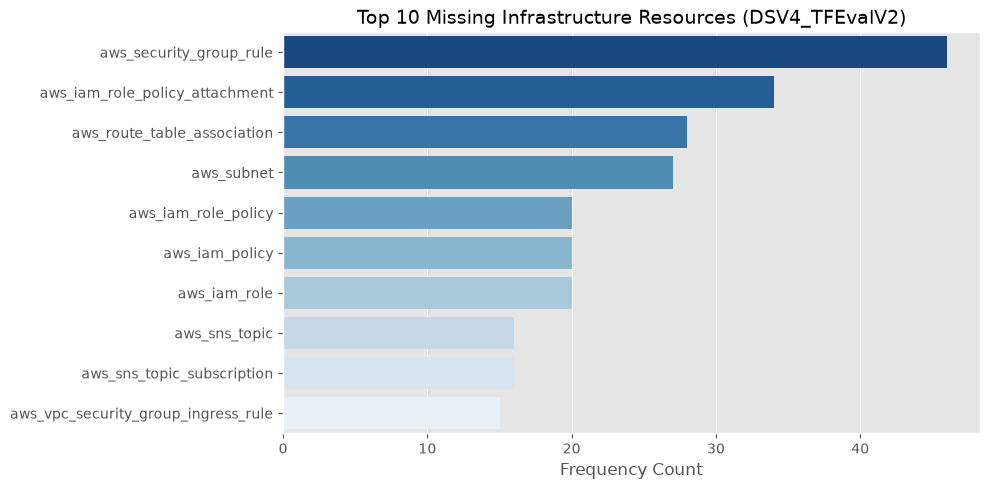

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_23232/257090815.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_extra, y='Resource Type', x='Frequency', palette='Oranges_r')


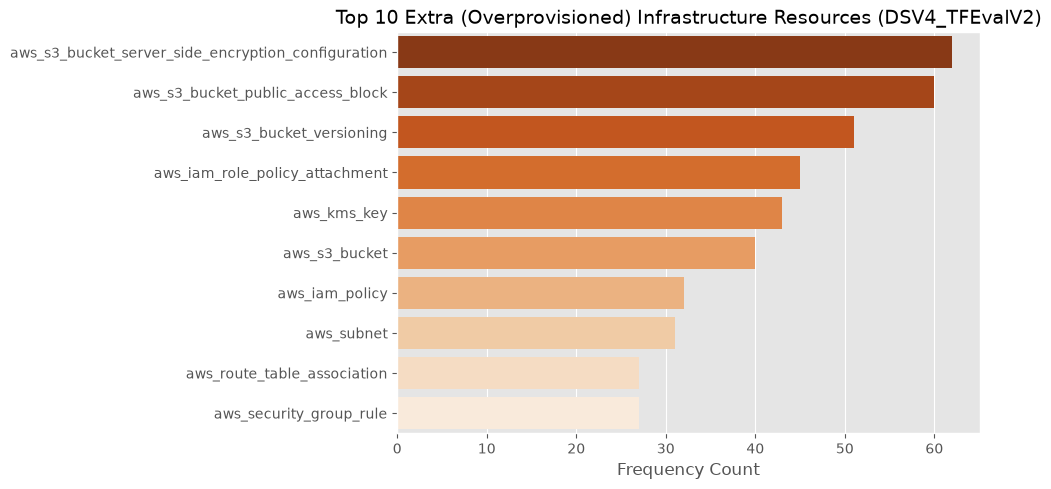

In [18]:
# ── 5. Top Missing and Extra Resource Types ───────────────────────────────────
# Note: We only plot "Resource" types here as variables and outputs usually have 
# arbitrary user-defined names that aren't useful to aggregate in a bar chart.

for model_name, df in merged_dataframes.items():
    missing_counter = Counter()
    extra_counter = Counter()

    missing_col = 'resource_missing_list' if 'resource_missing_list' in df.columns else 'missing_resource_types'
    extra_col = 'resource_extra_list' if 'resource_extra_list' in df.columns else 'extra_resource_types'

    if missing_col in df.columns:
        for items in df[missing_col].dropna():
            for item in str(items).split(';'):
                if item.strip():
                    missing_counter[item.strip()] += 1

    if extra_col in df.columns:
        for items in df[extra_col].dropna():
            for item in str(items).split(';'):
                if item.strip():
                    extra_counter[item.strip()] += 1

    top_missing = pd.DataFrame(missing_counter.most_common(10), columns=['Resource Type', 'Frequency'])
    top_extra = pd.DataFrame(extra_counter.most_common(10), columns=['Resource Type', 'Frequency'])

    if not top_missing.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_missing, y='Resource Type', x='Frequency', palette='Blues_r')
        plt.title(f'Top 10 Missing Infrastructure Resources ({model_name})', fontsize=14)
        plt.xlabel('Frequency Count')
        plt.ylabel('')
        plt.tight_layout()
        plt.show()

    if not top_extra.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_extra, y='Resource Type', x='Frequency', palette='Oranges_r')
        plt.title(f'Top 10 Extra (Overprovisioned) Infrastructure Resources ({model_name})', fontsize=14)
        plt.xlabel('Frequency Count')
        plt.ylabel('')
        plt.tight_layout()
        plt.show()

📊 Calculating Cumulative Pass Rates by Iteration Milestones...


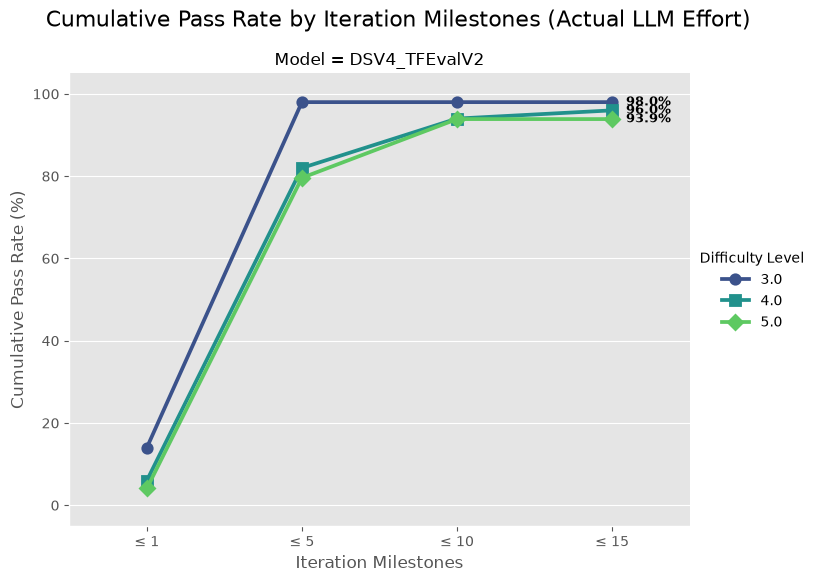

In [19]:
# In[15]:

# ── 6. Cumulative Pass Rate by Iteration Milestones ───────────────────────────
target_iterations = [1, 5, 10, 15]
iteration_stats = []

print("📊 Calculating Cumulative Pass Rates by Iteration Milestones...")
for model_name, df in merged_dataframes.items():
    diff_col = 'difficulty_level' if 'difficulty_level' in df.columns else 'difficulty'
    val_col = 'final_validation_passed' if 'final_validation_passed' in df.columns else ('deploy_pass' if 'deploy_pass' in df.columns else None)
    iter_col = 'iterations_used'

    if diff_col in df.columns and val_col in df.columns and iter_col in df.columns:
        # Ensure we're working with clean numeric data for iterations
        df[iter_col] = pd.to_numeric(df[iter_col], errors='coerce')
        
        for diff in sorted(df[diff_col].dropna().unique()):
            subset = df[df[diff_col] == diff]
            total_in_diff = len(subset)

            if total_in_diff == 0:
                continue

            for t_iter in target_iterations:
                # Condition: The generation ultimately passed AND it took <= N iterations
                passed_subset = subset[(subset[val_col] == 1) & (subset[iter_col] <= t_iter)]
                pass_rate = (len(passed_subset) / total_in_diff) * 100

                iteration_stats.append({
                    'Model': model_name,
                    'Difficulty Level': str(diff), # Convert to string for discrete legend
                    'Iteration Limit': f'≤ {t_iter}',
                    'Iteration_Num': t_iter, # Used purely for chronological sorting
                    'Pass Rate (%)': pass_rate
                })
    else:
        print(f"⚠️ Missing required columns for model {model_name}. Need difficulty, validation, and 'iterations_used'.")

if iteration_stats:
    iter_df = pd.DataFrame(iteration_stats).sort_values(by=['Model', 'Difficulty Level', 'Iteration_Num'])

    # Create a point plot to show progression over time (iterations)
    g = sns.catplot(
        data=iter_df, 
        kind="point",
        x="Iteration Limit", 
        y="Pass Rate (%)", 
        hue="Difficulty Level", 
        col="Model",
        palette="viridis", 
        height=5.5, 
        aspect=1.3,
        markers=["o", "s", "D", "^", "v"][:len(iter_df['Difficulty Level'].unique())],
        linestyles="-"
    )

    g.set_axis_labels("Iteration Milestones", "Cumulative Pass Rate (%)")
    g.set(ylim=(-5, 105))
    g.fig.suptitle('Cumulative Pass Rate by Iteration Milestones (Actual LLM Effort)', fontsize=16, y=1.05)

    # Add data labels for the final iteration milestone (15) to show the plateau ceiling
    for ax in g.axes.flat:
        for line in ax.lines:
            # Only label the last point (Iteration <= 15) for cleaner visuals
            if len(line.get_xdata()) > 0:
                x_last = line.get_xdata()[-1]
                y_last = line.get_ydata()[-1]
                if pd.notna(y_last):
                    ax.annotate(
                        f'{y_last:.1f}%', 
                        xy=(x_last, y_last), 
                        xytext=(10, 0),
                        textcoords='offset points',
                        ha='left', va='center',
                        fontsize=9,
                        fontweight='bold'
                    )

    plt.show()
else:
    print("⚠️ No valid data processed for iteration milestones.")

In [22]:
df.columns

Index(['row_number', 'ground_truth_path', 'run_id', 'status',
       'final_validation_passed', 'iterations_used', 'llm_calls_total',
       'token_all_tokens', 'token_input_tokens', 'token_output_tokens',
       'token_prompt_tokens', 'token_completion_tokens',
       'scenario_policy_pass_rate', 'filtered_compliance_rate',
       'unfiltered_compliance_rate', 'duration_seconds', 'error_message',
       'error_traceback', 'policy_total_policies', 'policy_passed_policies',
       'final_template', 'deploy_target', 'deploy_passed', 'deploy_stack_id',
       'deploy_error_message', 'deploy_logs', 'deploy_duration_seconds',
       'deploy_failed_resources', 'deploy_completed_resources',
       'total_yaml_errors', 'total_cfn_lint_errors', 'total_security_errors',
       'all_yaml_errors', 'all_cfn_lint_errors', 'all_security_errors',
       'latest_error_tflint', 'latest_error_terraform-validate',
       'latest_error_trivy', 'val_stage_tflint_passed',
       'val_stage_terraform-validate


DSV4_TFEvalV2: 3/149 scenarios (2.0%) below 30% on both coverage and accuracy.
  ⚠️ 2 of those still PASSED final validation despite the drift -- the generated stack was deployable/secure but unrelated to what was asked, which is exactly the failure mode coverage/accuracy scoring exists to catch (final_validation_passed alone would have hidden it).


,row_number,coverage_pct,accuracy_pct,final_validation_passed,ground_truth_path
0,20,0.00,0.00,True,iac_benchmark/scenarios/gh_3a4dde50
1,197,8.57,25.00,False,iac_benchmark/scenarios/terrads_8c3d60955e7f
2,22,25.00,14.29,True,iac_benchmark/scenarios/terrads_8ecc16737478


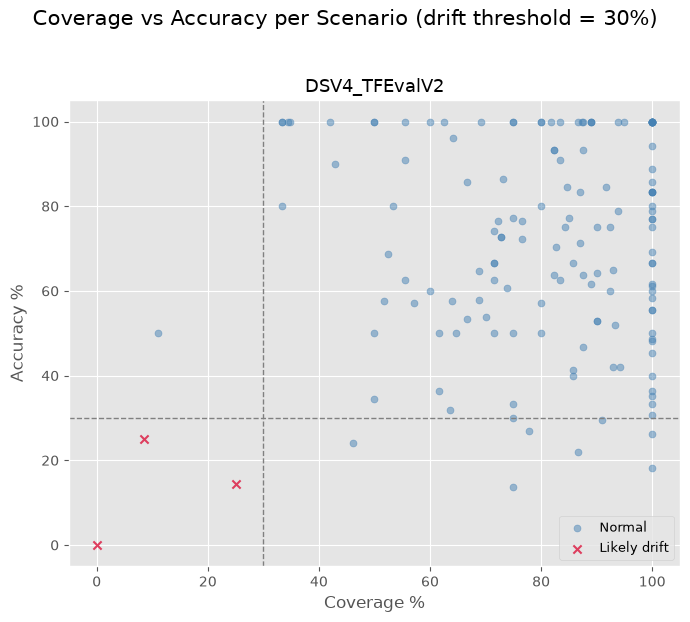

In [23]:
# ── 6. Low Coverage/Accuracy Scenario Audit (possible benchmark problems) ────
# Some rows come back with coverage/accuracy far below the model's typical
# performance even when the run itself completed and validated successfully.
# That pattern is a signal worth distinguishing into two different causes:
#   (a) the LLM genuinely drifted away from the prompt (generated something
#       unrelated), or
#   (b) the benchmark row itself is broken -- e.g. a ground-truth template
#       whose "required resources" can't reasonably be inferred from its own
#       prompt (see the "changed prompts" / "need resampling" notes below
#       from a previous manual pass over this exact symptom: several 0%-
#       coverage rows turned out to be AWS Config conformance-pack templates
#       that assume a Config Recorder/Delivery Channel already exists, or
#       templates built on deprecated resource types like the classic WAF).
# This cell makes that triage repeatable and reusable across all models in
# `input_pairs` instead of a one-off hardcoded printout.

# A scenario is flagged as "likely drift" only when BOTH coverage AND
# accuracy fall below the threshold together. Low coverage alone can mean
# "did the bare minimum but got it right" (e.g. cov=8% acc=100%), and low
# accuracy alone can mean "over-provisioned but covered everything asked"
# (e.g. cov=100% acc=24%) -- neither is "drifted away from the prompt" on
# its own. Only the combination -- it didn't build what was asked for AND
# what it did build mostly doesn't match -- indicates the output has little
# relationship to the prompt. 30% is a deliberately conservative floor: at
# a glance in the raw distribution, genuinely broken rows cluster at exactly
# 0% on both axes, so 30% still catches near-total misses without also
# flagging ordinary imperfect (but on-target) generations. Adjust here if a
# different run's distribution warrants it.
DRIFT_THRESHOLD_PCT = 30.0

scenario_diagnostics = {}

for model_name, df in merged_dataframes.items():
    if not {'resource_cov_pct', 'resource_acc_pct'}.issubset(df.columns):
        print(f"⚠️ Skipping {model_name}: no coverage_pct/accuracy_pct columns.")
        continue

    diag_cols = {
        'row_number': df.get('row_number'),
        'difficulty_level': df.get('difficulty_level'),
        'coverage_pct': df['resource_cov_pct'],
        'accuracy_pct': df['resource_acc_pct'],
        'final_validation_passed': df.get('final_validation_passed'),
        'deploy_passed': df.get('deploy_passed'),
        'run_status': df.get('status'),
        'required': df.get('total_required_resources'),
        'generated': df.get('total_generated_resources'),
        'correct': df.get('correct_resources'),
        'missing': df.get('missing_resources'),
        'extra': df.get('extra_resources'),
        'missing_resource_types': df.get('missing_resource_types'),
        'extra_resource_types': df.get('extra_resource_types'),
        'ground_truth_path': df.get('ground_truth_path'),
        'prompt': df.get('prompt'),
    }
    diag_df = pd.DataFrame({k: v for k, v in diag_cols.items() if v is not None})
    diag_df = diag_df.dropna(subset=['coverage_pct', 'accuracy_pct'])

    diag_df['likely_drift'] = (
        (diag_df['coverage_pct'] < DRIFT_THRESHOLD_PCT) &
        (diag_df['accuracy_pct'] < DRIFT_THRESHOLD_PCT)
    )

    scenario_diagnostics[model_name] = diag_df

    n_total = len(diag_df)
    n_flagged = diag_df['likely_drift'].sum()
    n_flagged_but_valid = ((diag_df['likely_drift']) & (diag_df['final_validation_passed'] == True)).sum() \
        if 'final_validation_passed' in diag_df.columns else 0

    print(f"\n{'='*90}\n{model_name}: {n_flagged}/{n_total} scenarios ({n_flagged / n_total:.1%}) "
          f"below {DRIFT_THRESHOLD_PCT:.0f}% on both coverage and accuracy.")
    if n_flagged_but_valid:
        print(f"  ⚠️ {n_flagged_but_valid} of those still PASSED final validation despite the drift -- "
              f"the generated stack was deployable/secure but unrelated to what was asked, which is "
              f"exactly the failure mode coverage/accuracy scoring exists to catch (final_validation_passed "
              f"alone would have hidden it).")

    if n_flagged:
        display_cols = ['row_number', 'difficulty_level', 'coverage_pct', 'accuracy_pct',
                         'final_validation_passed', 'required', 'generated', 'correct',
                         'missing', 'extra', 'ground_truth_path']
        display_cols = [c for c in display_cols if c in diag_df.columns]
        flagged = diag_df[diag_df['likely_drift']].sort_values('coverage_pct').reset_index(drop=True)
        with pd.option_context('display.max_colwidth', 80, 'display.width', 200):
            display(flagged[display_cols])

# ── Scatter: coverage vs accuracy, flagged scenarios highlighted ────────────
if scenario_diagnostics:
    n_models = len(scenario_diagnostics)
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6), squeeze=False)
    axes = axes[0]

    for ax, (model_name, diag_df) in zip(axes, scenario_diagnostics.items()):
        ok = diag_df[~diag_df['likely_drift']]
        bad = diag_df[diag_df['likely_drift']]
        ax.scatter(ok['coverage_pct'], ok['accuracy_pct'], alpha=0.5, s=25,
                   label='Normal', color='steelblue')
        ax.scatter(bad['coverage_pct'], bad['accuracy_pct'], alpha=0.8, s=35,
                   label='Likely drift', color='crimson', marker='x')
        ax.axvline(DRIFT_THRESHOLD_PCT, color='gray', linestyle='--', linewidth=1)
        ax.axhline(DRIFT_THRESHOLD_PCT, color='gray', linestyle='--', linewidth=1)
        ax.set_title(model_name, fontsize=13)
        ax.set_xlabel('Coverage %')
        ax.set_ylabel('Accuracy %')
        ax.set_xlim(-5, 105)
        ax.set_ylim(-5, 105)
        ax.legend(loc='lower right', fontsize=9)

    fig.suptitle(f'Coverage vs Accuracy per Scenario (drift threshold = {DRIFT_THRESHOLD_PCT:.0f}%)',
                 fontsize=15, y=1.03)
    plt.tight_layout()
    plt.show()


In [20]:
  # [   0] scenarios/terrads_2b3dc3e26799 | RES cov= 80.0% acc=100.0% [req=5  gen=4 ] | VAR cov=  2.7%
  # [   1] scenarios/terrads_037b2fe08aa0 | RES cov=100.0% acc= 45.5% [req=5  gen=11] | VAR cov= 18.6%
  # [   2] scenarios/terrads_c97056850842 | RES cov=100.0% acc=100.0% [req=15 gen=15] | VAR cov= 20.0%
  # [   3] enchmark/scenarios/gh_b7d56bc5 | RES cov= 11.1% acc= 50.0% [req=18 gen=4 ] | VAR cov=100.0%
  # [   4] enchmark/scenarios/gh_75c55509 | RES cov=100.0% acc= 80.0% [req=8  gen=10] | VAR cov=  3.2%
  # [   5] scenarios/terrads_ba0c51a35dac | RES cov= 72.7% acc= 72.7% [req=11 gen=11] | VAR cov=  0.0%
  # [   6] scenarios/terrads_b399f0e51686 | RES cov= 84.6% acc= 84.6% [req=13 gen=13] | VAR cov= 22.2%
  # [   7] scenarios/terrads_01d04d611b22 | RES cov= 57.1% acc= 57.1% [req=14 gen=14] | VAR cov=  0.0%
  # [   8] scenarios/terrads_01334dedc4eb | RES cov=100.0% acc=100.0% [req=19 gen=19] | VAR cov= 30.0%
  # [   9] enchmark/scenarios/gh_8159ec72 | RES cov= 92.9% acc= 41.9% [req=14 gen=31] | VAR cov=  3.2%
  # [  10] scenarios/terrads_84f64c0c2376 | RES cov= 92.9% acc= 61.9% [req=14 gen=21] | VAR cov= 22.6%
  # [  11] scenarios/terrads_c5fb6e784997 | RES cov=100.0% acc= 69.2% [req=18 gen=26] | VAR cov= 66.7%
  # [  12] scenarios/terrads_f5e9cc30bc08 | RES cov=100.0% acc= 40.0% [req=8  gen=20] | VAR cov=  1.3%
  # [  13] enchmark/scenarios/gh_3a4dde50 | RES cov=  0.0% acc=  0.0% [req=12 gen=4 ] | VAR cov= 25.5%
  # [  14] scenarios/terrads_8ecc16737478 | RES cov= 25.0% acc= 14.3% [req=8  gen=14] | VAR cov=  0.0%
  # [  15] scenarios/terrads_31b9a6dde088 | RES cov= 90.0% acc= 52.9% [req=10 gen=17] | VAR cov=  0.0%
  # [  16] enchmark/scenarios/gh_7b224d4a | RES cov=100.0% acc= 58.3% [req=7  gen=12] | VAR cov=  0.0%
  # [  17] scenarios/terrads_82192fbc1740 | RES cov= 82.3% acc= 63.6% [req=17 gen=22] | VAR cov=  3.1%
  # [  18] enchmark/scenarios/gh_0af37618 | RES cov=100.0% acc=100.0% [req=10 gen=10] | VAR cov= 83.3%
  # [  19] scenarios/terrads_b26db08be605 | RES cov= 63.9% acc= 57.5% [req=36 gen=40] | VAR cov=  0.0%
  # [  20] scenarios/terrads_e0aca3ee1a17 | RES cov= 88.9% acc=100.0% [req=9  gen=8 ] | VAR cov= 80.0%
  # [  21] scenarios/terrads_25476de431a3 | RES cov= 75.0% acc= 50.0% [req=8  gen=12] | VAR cov=  6.7%
  # [  22] scenarios/terrads_2a8715e9108a | RES cov= 70.0% acc= 53.9% [req=10 gen=13] | VAR cov=  0.0%
  # [  23] scenarios/terrads_765efd6394eb | RES cov= 55.6% acc= 62.5% [req=9  gen=8 ] | VAR cov=  2.3%
  # [  24] scenarios/terrads_3e8cb545e8ce | RES cov= 80.0% acc= 80.0% [req=5  gen=5 ] | VAR cov=  0.0%
  # [  25] enchmark/scenarios/gh_6f9b1167 | RES cov= 72.2% acc= 76.5% [req=18 gen=17] | VAR cov=100.0%
  # [  26] scenarios/terrads_9d168e7478ae | RES cov= 87.5% acc= 93.3% [req=16 gen=15] | VAR cov=100.0%
  # [  27] scenarios/terrads_f60d1837f9eb | RES cov= 73.1% acc= 86.4% [req=26 gen=22] | VAR cov=  3.8%
  # [  28] scenarios/terrads_6516229c5944 | RES cov= 87.5% acc= 63.6% [req=8  gen=11] | VAR cov=  0.0%
  # [  29] scenarios/terrads_11585d5feec9 | RES cov= 63.6% acc= 31.8% [req=11 gen=22] | VAR cov=  0.0%
  # [  30] enchmark/scenarios/gh_88540324 | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov=  8.3%
  # [  31] scenarios/terrads_202ad9eccfce | RES cov=100.0% acc= 48.1% [req=26 gen=54] | VAR cov=  0.0%
  # [  32] scenarios/terrads_48ad8a91b6a4 | RES cov= 93.8% acc= 57.7% [req=16 gen=26] | VAR cov= 28.6%
  # [  33] enchmark/scenarios/gh_8963e028 | RES cov=100.0% acc=100.0% [req=7  gen=7 ] | VAR cov= 19.2%
  # [  34] scenarios/terrads_24c03d00dfc1 | RES cov= 33.3% acc=100.0% [req=9  gen=3 ] | VAR cov=100.0%
  # [  35] scenarios/terrads_967b5442ed58 | RES cov= 41.9% acc=100.0% [req=31 gen=13] | VAR cov=  0.0%
  # [  36] scenarios/terrads_502f773ea348 | RES cov= 75.0% acc=100.0% [req=8  gen=6 ] | VAR cov= 12.5%
  # [  37] enchmark/scenarios/gh_ee089b0d | RES cov= 68.8% acc= 57.9% [req=16 gen=19] | VAR cov=  0.0%
  # [  38] scenarios/terrads_b4c86b74a08f | RES cov= 71.4% acc= 74.1% [req=28 gen=27] | VAR cov=  2.7%
  # [  39] scenarios/terrads_d85ca07b31c2 | RES cov= 87.0% acc= 71.4% [req=23 gen=28] | VAR cov=  0.0%
  # [  40] scenarios/terrads_bf99d2d68ca6 | RES cov= 72.7% acc= 72.7% [req=11 gen=11] | VAR cov= 44.4%
  # [  41] scenarios/terrads_726ca27fa34a | RES cov=100.0% acc= 26.3% [req=5  gen=19] | VAR cov= 32.0%
  # [  42] scenarios/terrads_5a206a75e8f1 | RES cov= 34.8% acc=100.0% [req=23 gen=8 ] | VAR cov=  0.0%
  # [  43] scenarios/terrads_6f97821a57ad | RES cov=100.0% acc= 48.0% [req=12 gen=25] | VAR cov=  0.0%
  # [  44] enchmark/scenarios/gh_3ec69cfa | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov=  8.0%
  # [  45] scenarios/terrads_1def7c8627ad | RES cov= 95.0% acc=100.0% [req=20 gen=19] | VAR cov=  0.0%
  # [  46] scenarios/terrads_73cb6ac4fe1b | RES cov= 66.7% acc= 53.3% [req=12 gen=15] | VAR cov= 11.5%
  # [  47] scenarios/terrads_3857b74fe599 | RES cov= 91.7% acc= 84.6% [req=12 gen=13] | VAR cov= 20.0%
  # [  48] scenarios/terrads_572e7016b959 | RES cov= 71.4% acc= 50.0% [req=7  gen=10] | VAR cov=  0.0%
  # [  49] scenarios/terrads_6bc966772840 | RES cov=100.0% acc=100.0% [req=61 gen=61] | VAR cov=  0.0%
  # [  50] scenarios/terrads_586a9474fd96 | RES cov= 83.3% acc= 83.3% [req=6  gen=6 ] | VAR cov= 57.1%
  # [  51] enchmark/scenarios/gh_254d7b8f | RES cov= 88.9% acc=100.0% [req=9  gen=8 ] | VAR cov=  1.4%
  # [  52] scenarios/terrads_2cf4c191fb3a | RES cov= 87.5% acc= 46.7% [req=16 gen=30] | VAR cov=  5.6%
  # [  53] scenarios/terrads_8945dba1c1be | RES cov= 76.5% acc= 76.5% [req=17 gen=17] | VAR cov=  9.1%
  # [  54] scenarios/terrads_b925822efe24 | RES cov= 83.3% acc= 90.9% [req=12 gen=11] | VAR cov=100.0%
  # [  55] scenarios/terrads_bcebc593f734 | RES cov= 46.1% acc= 24.0% [req=13 gen=25] | VAR cov=  0.0%
  # [  56] scenarios/terrads_b17fbb76ac06 | RES cov= 85.7% acc= 40.0% [req=14 gen=30] | VAR cov=  4.3%
  # [  57] scenarios/terrads_0b839c616027 | RES cov= 33.3% acc=100.0% [req=6  gen=2 ] | VAR cov=  0.0%
  # [  58] scenarios/terrads_7ed20d06a531 | RES cov= 86.7% acc= 22.0% [req=15 gen=59] | VAR cov=  0.0%
  # [  59] scenarios/terrads_aacf53e04510 | RES cov= 82.3% acc= 93.3% [req=17 gen=15] | VAR cov=  7.7%
  # [  60] scenarios/terrads_d16402204370 | RES cov= 69.2% acc=100.0% [req=13 gen=9 ] | VAR cov=100.0%
  # [  61] scenarios/terrads_84e168b0fe71 | RES cov=100.0% acc=100.0% [req=7  gen=7 ] | VAR cov=  0.0%
  # [  62] scenarios/terrads_9adbd7969ed1 | RES cov= 51.7% acc= 57.7% [req=29 gen=26] | VAR cov=  0.0%
  # [  63] scenarios/terrads_1db4706734d9 | RES cov=100.0% acc= 55.6% [req=5  gen=9 ] | VAR cov=  3.5%
  # [  64] scenarios/terrads_c41e7c31c21b | RES cov= 90.0% acc= 52.9% [req=10 gen=17] | VAR cov=  3.7%
  # [  65] scenarios/terrads_e6f040aa6f83 | RES cov=100.0% acc= 50.0% [req=6  gen=12] | VAR cov=  0.0%
  # [  66] scenarios/terrads_c92b260bc738 | RES cov=100.0% acc= 75.0% [req=12 gen=16] | VAR cov=  2.1%
  # [  67] scenarios/terrads_b7c7bfa5a44c | RES cov=100.0% acc= 61.1% [req=11 gen=18] | VAR cov= 33.3%
  # [  68] scenarios/terrads_3460cbdc48ca | RES cov= 34.4% acc=100.0% [req=61 gen=21] | VAR cov=  0.0%
  # [  69] scenarios/terrads_7128db805974 | RES cov=100.0% acc= 94.1% [req=16 gen=17] | VAR cov=  0.0%
  # [  70] scenarios/terrads_f47d8c533f10 | RES cov= 83.3% acc=100.0% [req=12 gen=10] | VAR cov=  0.0%
  # [  71] scenarios/terrads_e23b184d6cd1 | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov= 18.8%
  # [  72] scenarios/terrads_5f7ef1fec7f9 | RES cov= 87.5% acc=100.0% [req=8  gen=7 ] | VAR cov= 14.3%
  # [  73] scenarios/terrads_e3a38ad9c4b0 | RES cov= 11.1% acc= 40.0% [req=18 gen=5 ] | VAR cov=  6.5%
  # [  74] scenarios/terrads_c07b7cea2171 | RES cov= 80.0% acc=100.0% [req=10 gen=8 ] | VAR cov= 11.1%
  # [  75] scenarios/terrads_251b1cc05888 | RES cov= 93.8% acc= 79.0% [req=16 gen=19] | VAR cov=  0.0%
  # [  76] scenarios/terrads_48c79ba1984e | RES cov= 60.0% acc=100.0% [req=10 gen=6 ] | VAR cov= 12.5%
  # [  77] scenarios/terrads_8590a5006532 | RES cov= 80.0% acc= 57.1% [req=5  gen=7 ] | VAR cov=  0.0%
  # [  78] scenarios/terrads_2d7923019d0c | RES cov= 75.0% acc=100.0% [req=16 gen=12] | VAR cov= 25.7%
  # [  79] scenarios/terrads_f06187331dff | RES cov= 66.7% acc= 42.9% [req=9  gen=14] | VAR cov=  4.5%
  # [  80] scenarios/terrads_305fc30c5f79 | RES cov=100.0% acc=100.0% [req=9  gen=9 ] | VAR cov= 15.0%
  # [  81] scenarios/terrads_862e56e7423d | RES cov=100.0% acc= 18.2% [req=4  gen=22] | VAR cov=  3.2%
  # [  82] scenarios/terrads_7b48683a13ff | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov=100.0%
  # [  83] scenarios/terrads_8703dd211a7d | RES cov= 64.7% acc= 50.0% [req=17 gen=22] | VAR cov= 33.3%
  # [  84] scenarios/terrads_1ab0fa194791 | RES cov= 90.0% acc= 75.0% [req=10 gen=12] | VAR cov= 20.0%
  # [  85] scenarios/terrads_58f499b02851 | RES cov= 75.0% acc= 30.0% [req=4  gen=10] | VAR cov=  0.0%
  # [  86] scenarios/terrads_51c59e2a63d8 | RES cov= 75.0% acc= 13.6% [req=4  gen=22] | VAR cov= 17.2%
  # [  87] scenarios/terrads_b86b0244fd6d | RES cov= 85.7% acc= 41.4% [req=14 gen=29] | VAR cov= 48.1%
  # [  88] scenarios/terrads_9eab77581581 | RES cov= 76.5% acc= 72.2% [req=17 gen=18] | VAR cov=  0.0%
  # [  89] scenarios/terrads_46556c7a134d | RES cov= 90.9% acc= 29.4% [req=11 gen=34] | VAR cov=  0.0%
  # [  90] enchmark/scenarios/gh_570735ea | RES cov=100.0% acc= 75.0% [req=9  gen=12] | VAR cov=100.0%
  # [  91] scenarios/terrads_1d6f0e58e59c | RES cov=100.0% acc= 83.3% [req=5  gen=6 ] | VAR cov=  0.0%
  # [  92] enchmark/scenarios/gh_e1731993 | RES cov= 53.3% acc= 80.0% [req=15 gen=10] | VAR cov=  0.0%
  # [  93] scenarios/terrads_f86afb58a0d5 | RES cov=100.0% acc= 63.2% [req=12 gen=19] | VAR cov=  5.0%
  # [  94] scenarios/terrads_4737a6037a87 | RES cov= 75.0% acc=100.0% [req=16 gen=12] | VAR cov=  0.0%
  # [  95] scenarios/terrads_dcfd05f3ba14 | RES cov=100.0% acc= 91.0% [req=61 gen=67] | VAR cov=  0.0%
  # [  96] scenarios/terrads_1fe0c7e96181 | RES cov= 82.3% acc= 93.3% [req=17 gen=15] | VAR cov=  5.3%
  # [  97] scenarios/terrads_c5f20f79e141 | RES cov= 94.1% acc= 42.1% [req=17 gen=38] | VAR cov= 50.0%
  # [  98] scenarios/terrads_79d499359f89 | RES cov=100.0% acc= 30.8% [req=4  gen=13] | VAR cov=  8.0%
  # [  99] scenarios/terrads_e0431c1caace | RES cov=100.0% acc= 33.3% [req=10 gen=30] | VAR cov=  0.0%
  # [ 100] scenarios/terrads_5b4e0301422a | RES cov= 60.0% acc= 60.0% [req=5  gen=5 ] | VAR cov=  0.0%
  # [ 101] scenarios/terrads_cef8614423be | RES cov= 75.0% acc= 33.3% [req=4  gen=9 ] | VAR cov= 25.0%
  # [ 102] scenarios/terrads_77969f786de6 | RES cov= 75.0% acc= 77.1% [req=36 gen=35] | VAR cov=100.0%
  # [ 103] scenarios/terrads_5c95653f2b2b | RES cov=100.0% acc= 66.7% [req=8  gen=12] | VAR cov= 66.7%
  # [ 104] scenarios/terrads_05edc40999d7 | RES cov= 93.3% acc= 51.9% [req=15 gen=27] | VAR cov=  0.0%
  # [ 105] scenarios/terrads_ddc425a81cf2 | RES cov=100.0% acc= 66.7% [req=10 gen=15] | VAR cov= 17.1%
  # [ 106] scenarios/terrads_916c37ccf307 | RES cov= 94.7% acc= 50.0% [req=19 gen=36] | VAR cov= 20.0%
  # [ 107] enchmark/scenarios/gh_1d5f4d32 | RES cov= 88.9% acc=100.0% [req=9  gen=8 ] | VAR cov=  4.0%
  # [ 108] scenarios/terrads_0ee2a2760917 | RES cov=100.0% acc= 55.6% [req=5  gen=9 ] | VAR cov= 42.9%
  # [ 109] scenarios/terrads_e4f73489147c | RES cov= 85.7% acc= 66.7% [req=28 gen=36] | VAR cov=100.0%
  # [ 110] scenarios/terrads_a78e858914da | RES cov= 86.7% acc=100.0% [req=15 gen=13] | VAR cov=  0.0%
  # [ 111] scenarios/terrads_bb382f0f3fd1 | RES cov= 92.9% acc= 65.0% [req=14 gen=20] | VAR cov= 33.3%
  # [ 112] scenarios/terrads_f4222681f712 | RES cov= 92.3% acc= 75.0% [req=13 gen=16] | VAR cov= 30.0%
  # [ 113] scenarios/terrads_2b8b3dc2bc75 | RES cov= 77.8% acc= 26.9% [req=9  gen=26] | VAR cov=  0.0%
  # [ 114] scenarios/terrads_8c3d60955e7f | RES cov=  8.6% acc= 25.0% [req=35 gen=12] | VAR cov= 66.7%
  # [ 115] scenarios/terrads_6ec75c3ea43a | RES cov=100.0% acc= 76.9% [req=10 gen=13] | VAR cov=  0.0%
  # [ 116] scenarios/terrads_83b303c27ebb | RES cov=100.0% acc= 60.0% [req=12 gen=20] | VAR cov=  4.1%
  # [ 117] scenarios/terrads_39c90624ffed | RES cov=  0.0% acc=  0.0% [req=12 gen=10] | VAR cov=  6.4%
  # [ 118] scenarios/terrads_4ce463879462 | RES cov=100.0% acc= 30.8% [req=4  gen=13] | VAR cov=  0.0%
  # [ 119] scenarios/terrads_15dc7dba11b2 | RES cov= 83.3% acc= 62.5% [req=12 gen=16] | VAR cov=  2.6%
  # [ 120] scenarios/terrads_a6b6f6412452 | RES cov= 71.4% acc= 62.5% [req=14 gen=16] | VAR cov=  0.0%
  # [ 121] scenarios/terrads_265d051c70be | RES cov=100.0% acc= 88.9% [req=16 gen=18] | VAR cov=  3.7%
  # [ 122] scenarios/terrads_1b435e3d4172 | RES cov= 88.9% acc= 61.5% [req=9  gen=13] | VAR cov=  0.0%
  # [ 123] scenarios/terrads_c6dcc9b29983 | RES cov=100.0% acc= 37.8% [req=14 gen=37] | VAR cov=  3.2%
  # [ 124] scenarios/terrads_bf3ef706d7fd | RES cov= 50.0% acc= 34.5% [req=20 gen=29] | VAR cov=  0.0%
  # [ 125] scenarios/terrads_c8bf6bcc3019 | RES cov=100.0% acc= 83.3% [req=15 gen=18] | VAR cov=  0.0%
  # [ 126] scenarios/terrads_8a18be3138e9 | RES cov= 42.9% acc= 90.0% [req=21 gen=10] | VAR cov=100.0%
  # [ 127] scenarios/terrads_8ac6bda76d9a | RES cov= 22.2% acc=100.0% [req=18 gen=4 ] | VAR cov=  9.7%
  # [ 128] scenarios/terrads_8b175cdbe2cf | RES cov= 73.9% acc= 60.7% [req=23 gen=28] | VAR cov=100.0%
  # [ 129] scenarios/terrads_33766381a4b4 | RES cov= 55.6% acc= 90.9% [req=18 gen=11] | VAR cov=  9.7%
  # [ 130] scenarios/terrads_0bc9721da849 | RES cov=100.0% acc= 79.0% [req=15 gen=19] | VAR cov=100.0%
  # [ 131] scenarios/terrads_52b67e410bd8 | RES cov= 90.0% acc= 64.3% [req=10 gen=14] | VAR cov=  0.0%
  # [ 132] scenarios/terrads_9da16fbef056 | RES cov=100.0% acc=100.0% [req=5  gen=5 ] | VAR cov= 41.7%
  # [ 133] scenarios/terrads_b1409427bd33 | RES cov= 71.4% acc= 66.7% [req=14 gen=15] | VAR cov=  0.0%
  # [ 134] scenarios/terrads_71c036ff15e5 | RES cov= 55.6% acc= 90.9% [req=18 gen=11] | VAR cov= 16.1%
  # [ 135] scenarios/terrads_2e8035ffc09c | RES cov=100.0% acc= 83.3% [req=5  gen=6 ] | VAR cov= 57.1%
  # [ 136] enchmark/scenarios/gh_288218eb | RES cov= 80.0% acc= 50.0% [req=5  gen=8 ] | VAR cov=  4.0%
  # [ 137] scenarios/terrads_9a807e8b7301 | RES cov=100.0% acc= 61.5% [req=8  gen=13] | VAR cov= 20.8%
  # [ 138] scenarios/terrads_de2463de7604 | RES cov=100.0% acc= 35.3% [req=6  gen=17] | VAR cov= 33.3%
  # [ 139] scenarios/terrads_c6fa801d3646 | RES cov= 50.0% acc=100.0% [req=6  gen=3 ] | VAR cov=  0.0%
  # [ 140] scenarios/terrads_ec610e61db0b | RES cov= 64.1% acc= 96.2% [req=39 gen=26] | VAR cov=  0.0%
  # [ 141] scenarios/terrads_9018d22f359d | RES cov= 93.8% acc=100.0% [req=16 gen=15] | VAR cov= 12.5%
  # [ 142] scenarios/terrads_253bca1f8ff4 | RES cov= 68.8% acc= 64.7% [req=16 gen=17] | VAR cov=  0.0%
  # [ 143] scenarios/terrads_54aa27d47fd9 | RES cov=100.0% acc= 36.4% [req=4  gen=11] | VAR cov= 12.0%
  # [ 144] scenarios/terrads_375e81039f24 | RES cov= 81.8% acc=100.0% [req=22 gen=18] | VAR cov= 14.3%
  # [ 145] scenarios/terrads_c2af7a854318 | RES cov= 52.4% acc= 68.8% [req=21 gen=16] | VAR cov= 40.0%
  # [ 146] enchmark/scenarios/gh_48c5e87c | RES cov=100.0% acc= 83.3% [req=5  gen=6 ] | VAR cov=  5.4%
  # [ 147] enchmark/scenarios/gh_131320ab | RES cov= 62.5% acc=100.0% [req=8  gen=5 ] | VAR cov= 50.0%
  # [ 148] scenarios/terrads_b0a44418031a | RES cov=100.0% acc=100.0% [req=10 gen=10] | VAR cov=  0.0%
  # [ 149] scenarios/terrads_4fd109e76acd | RES cov= 38.9% acc= 46.7% [req=18 gen=15] | VAR cov= 50.0%

In [ ]:
# [INFO] Benchmark loaded : iac_benchmark/dataset/tf_benchmark_diff_345.csv  (150 entries)
# [INFO] Input CSV loaded : result/iacgod/TFEvalV2_DeepseekV4Flash_security_runs.csv  (150 rows)

#   [   0] scenarios/terrads_2b3dc3e26799 | RES cov= 80.0% acc=100.0% [req=5  gen=4 ] | VAR cov=  2.7%
#   [   1] scenarios/terrads_037b2fe08aa0 | RES cov=100.0% acc= 45.5% [req=5  gen=11] | VAR cov= 18.6%
#   [   2] scenarios/terrads_c97056850842 | RES cov=100.0% acc=100.0% [req=15 gen=15] | VAR cov= 20.0%
#   [   3] enchmark/scenarios/gh_b7d56bc5 | RES cov= 11.1% acc= 50.0% [req=18 gen=4 ] | VAR cov=100.0%
#   [   4] enchmark/scenarios/gh_75c55509 | RES cov=100.0% acc= 80.0% [req=8  gen=10] | VAR cov=  3.2%
#   [   5] scenarios/terrads_ba0c51a35dac | RES cov= 72.7% acc= 72.7% [req=11 gen=11] | VAR cov=  0.0%
#   [   6] scenarios/terrads_b399f0e51686 | RES cov= 84.6% acc= 84.6% [req=13 gen=13] | VAR cov= 22.2%
#   [   7] scenarios/terrads_01d04d611b22 | RES cov= 57.1% acc= 57.1% [req=14 gen=14] | VAR cov=  0.0%
#   [   8] scenarios/terrads_01334dedc4eb | RES cov=100.0% acc=100.0% [req=19 gen=19] | VAR cov= 30.0%
#   [   9] enchmark/scenarios/gh_8159ec72 | RES cov= 92.9% acc= 41.9% [req=14 gen=31] | VAR cov=  3.2%
#   [  10] scenarios/terrads_c5fb6e784997 | RES cov=100.0% acc= 69.2% [req=18 gen=26] | VAR cov= 66.7%
#   [  11] scenarios/terrads_f5e9cc30bc08 | RES cov=100.0% acc= 40.0% [req=8  gen=20] | VAR cov=  1.3%
#   [  12] enchmark/scenarios/gh_3a4dde50 | RES cov=  0.0% acc=  0.0% [req=12 gen=4 ] | VAR cov= 25.5%
#   [  13] scenarios/terrads_8ecc16737478 | RES cov= 25.0% acc= 14.3% [req=8  gen=14] | VAR cov=  0.0%
#   [  14] scenarios/terrads_31b9a6dde088 | RES cov= 90.0% acc= 52.9% [req=10 gen=17] | VAR cov=  0.0%
#   [  15] enchmark/scenarios/gh_7b224d4a | RES cov=100.0% acc= 58.3% [req=7  gen=12] | VAR cov=  0.0%
#   [  16] scenarios/terrads_82192fbc1740 | RES cov= 82.3% acc= 63.6% [req=17 gen=22] | VAR cov=  3.1%
#   [  17] enchmark/scenarios/gh_0af37618 | RES cov=100.0% acc=100.0% [req=10 gen=10] | VAR cov= 83.3%
#   [  18] scenarios/terrads_b26db08be605 | RES cov= 63.9% acc= 57.5% [req=36 gen=40] | VAR cov=  0.0%
#   [  19] scenarios/terrads_e0aca3ee1a17 | RES cov= 88.9% acc=100.0% [req=9  gen=8 ] | VAR cov= 80.0%
#   [  20] scenarios/terrads_25476de431a3 | RES cov= 75.0% acc= 50.0% [req=8  gen=12] | VAR cov=  0.0%
#   [  21] scenarios/terrads_2a8715e9108a | RES cov= 70.0% acc= 53.9% [req=10 gen=13] | VAR cov=  0.0%
#   [  22] scenarios/terrads_765efd6394eb | RES cov= 55.6% acc= 62.5% [req=9  gen=8 ] | VAR cov=  2.3%
#   [  23] scenarios/terrads_3e8cb545e8ce | RES cov= 80.0% acc= 80.0% [req=5  gen=5 ] | VAR cov=  0.0%
#   [  24] enchmark/scenarios/gh_6f9b1167 | RES cov= 72.2% acc= 76.5% [req=18 gen=17] | VAR cov=100.0%
#   [  25] scenarios/terrads_9d168e7478ae | RES cov= 87.5% acc= 93.3% [req=16 gen=15] | VAR cov=100.0%
#   [  26] scenarios/terrads_f60d1837f9eb | RES cov= 73.1% acc= 86.4% [req=26 gen=22] | VAR cov=  3.8%
#   [  27] scenarios/terrads_6516229c5944 | RES cov= 87.5% acc= 63.6% [req=8  gen=11] | VAR cov=  0.0%
#   [  28] scenarios/terrads_11585d5feec9 | RES cov= 63.6% acc= 31.8% [req=11 gen=22] | VAR cov=  0.0%
#   [  29] enchmark/scenarios/gh_88540324 | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov=  8.3%
#   [  30] scenarios/terrads_202ad9eccfce | RES cov=100.0% acc= 48.1% [req=26 gen=54] | VAR cov=  0.0%
#   [  31] enchmark/scenarios/gh_8963e028 | RES cov=100.0% acc=100.0% [req=7  gen=7 ] | VAR cov= 19.2%
#   [  32] scenarios/terrads_24c03d00dfc1 | RES cov= 33.3% acc=100.0% [req=9  gen=3 ] | VAR cov=100.0%
#   [  33] scenarios/terrads_967b5442ed58 | RES cov= 41.9% acc=100.0% [req=31 gen=13] | VAR cov=  0.0%
#   [  34] scenarios/terrads_502f773ea348 | RES cov= 75.0% acc=100.0% [req=8  gen=6 ] | VAR cov= 12.5%
#   [  35] enchmark/scenarios/gh_ee089b0d | RES cov= 68.8% acc= 57.9% [req=16 gen=19] | VAR cov=  0.0%
#   [  36] scenarios/terrads_b4c86b74a08f | RES cov= 71.4% acc= 74.1% [req=28 gen=27] | VAR cov=  2.7%
#   [  37] scenarios/terrads_d85ca07b31c2 | RES cov= 87.0% acc= 71.4% [req=23 gen=28] | VAR cov=  0.0%
#   [  38] scenarios/terrads_bf99d2d68ca6 | RES cov= 72.7% acc= 72.7% [req=11 gen=11] | VAR cov= 44.4%
#   [  39] scenarios/terrads_726ca27fa34a | RES cov=100.0% acc= 26.3% [req=5  gen=19] | VAR cov= 32.0%
#   [  40] scenarios/terrads_5a206a75e8f1 | RES cov= 34.8% acc=100.0% [req=23 gen=8 ] | VAR cov=  0.0%
#   [  41] enchmark/scenarios/gh_3ec69cfa | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov=  8.0%
#   [  42] scenarios/terrads_1def7c8627ad | RES cov= 95.0% acc=100.0% [req=20 gen=19] | VAR cov=  0.0%
#   [  43] scenarios/terrads_73cb6ac4fe1b | RES cov= 66.7% acc= 53.3% [req=12 gen=15] | VAR cov= 11.5%
#   [  44] scenarios/terrads_3857b74fe599 | RES cov= 91.7% acc= 84.6% [req=12 gen=13] | VAR cov= 20.0%
#   [  45] scenarios/terrads_572e7016b959 | RES cov= 71.4% acc= 50.0% [req=7  gen=10] | VAR cov=  0.0%
#   [  46] enchmark/scenarios/gh_254d7b8f | RES cov= 88.9% acc=100.0% [req=9  gen=8 ] | VAR cov=  1.4%
#   [  47] scenarios/terrads_2cf4c191fb3a | RES cov= 87.5% acc= 46.7% [req=16 gen=30] | VAR cov=  5.6%
#   [  48] scenarios/terrads_8945dba1c1be | RES cov= 76.5% acc= 76.5% [req=17 gen=17] | VAR cov=  9.1%
#   [  49] scenarios/terrads_b925822efe24 | RES cov= 83.3% acc= 90.9% [req=12 gen=11] | VAR cov=100.0%
#   [  50] scenarios/terrads_bcebc593f734 | RES cov= 46.1% acc= 24.0% [req=13 gen=25] | VAR cov=  0.0%
#   [  51] scenarios/terrads_b17fbb76ac06 | RES cov= 85.7% acc= 40.0% [req=14 gen=30] | VAR cov=  4.3%
#   [  52] scenarios/terrads_0b839c616027 | RES cov= 33.3% acc=100.0% [req=6  gen=2 ] | VAR cov=  0.0%
#   [  53] scenarios/terrads_7ed20d06a531 | RES cov= 86.7% acc= 22.0% [req=15 gen=59] | VAR cov=  0.0%
#   [  54] scenarios/terrads_aacf53e04510 | RES cov= 82.3% acc= 93.3% [req=17 gen=15] | VAR cov=  7.7%
#   [  55] scenarios/terrads_d16402204370 | RES cov= 69.2% acc=100.0% [req=13 gen=9 ] | VAR cov=100.0%
#   [  56] scenarios/terrads_84e168b0fe71 | RES cov=100.0% acc=100.0% [req=7  gen=7 ] | VAR cov=  0.0%
#   [  57] scenarios/terrads_9adbd7969ed1 | RES cov= 51.7% acc= 57.7% [req=29 gen=26] | VAR cov=  0.0%
#   [  58] scenarios/terrads_1db4706734d9 | RES cov=100.0% acc= 55.6% [req=5  gen=9 ] | VAR cov=  3.5%
#   [  59] scenarios/terrads_c41e7c31c21b | RES cov= 90.0% acc= 52.9% [req=10 gen=17] | VAR cov=  3.7%
#   [  60] scenarios/terrads_e6f040aa6f83 | RES cov=100.0% acc= 50.0% [req=6  gen=12] | VAR cov=  0.0%
#   [  61] scenarios/terrads_b7c7bfa5a44c | RES cov=100.0% acc= 61.1% [req=11 gen=18] | VAR cov= 33.3%
#   [  62] scenarios/terrads_3460cbdc48ca | RES cov= 34.4% acc=100.0% [req=61 gen=21] | VAR cov=  0.0%
#   [  63] scenarios/terrads_7128db805974 | RES cov=100.0% acc= 94.1% [req=16 gen=17] | VAR cov=  0.0%
#   [  64] scenarios/terrads_f47d8c533f10 | RES cov= 83.3% acc=100.0% [req=12 gen=10] | VAR cov=  0.0%
#   [  65] scenarios/terrads_e23b184d6cd1 | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov= 18.8%
#   [  66] scenarios/terrads_5f7ef1fec7f9 | RES cov= 87.5% acc=100.0% [req=8  gen=7 ] | VAR cov= 14.3%
#   [  67] enchmark/scenarios/gh_26cf949a | RES cov= 50.0% acc= 50.0% [req=4  gen=4 ] | VAR cov=  0.0%
#   [  68] scenarios/terrads_c07b7cea2171 | RES cov= 80.0% acc=100.0% [req=10 gen=8 ] | VAR cov= 11.1%
#   [  69] scenarios/terrads_251b1cc05888 | RES cov= 93.8% acc= 79.0% [req=16 gen=19] | VAR cov=  0.0%
#   [  70] scenarios/terrads_48c79ba1984e | RES cov= 60.0% acc=100.0% [req=10 gen=6 ] | VAR cov= 12.5%
#   [  71] scenarios/terrads_8590a5006532 | RES cov= 80.0% acc= 57.1% [req=5  gen=7 ] | VAR cov=  0.0%
#   [  72] scenarios/terrads_305fc30c5f79 | RES cov=100.0% acc=100.0% [req=9  gen=9 ] | VAR cov= 15.0%
#   [  73] scenarios/terrads_862e56e7423d | RES cov=100.0% acc= 18.2% [req=4  gen=22] | VAR cov=  3.2%
#   [  74] scenarios/terrads_7b48683a13ff | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov=100.0%
#   [  75] scenarios/terrads_8703dd211a7d | RES cov= 64.7% acc= 50.0% [req=17 gen=22] | VAR cov= 33.3%
#   [  76] scenarios/terrads_1ab0fa194791 | RES cov= 90.0% acc= 75.0% [req=10 gen=12] | VAR cov= 20.0%
#   [  77] scenarios/terrads_58f499b02851 | RES cov= 75.0% acc= 30.0% [req=4  gen=10] | VAR cov=  0.0%
#   [  78] scenarios/terrads_51c59e2a63d8 | RES cov= 75.0% acc= 13.6% [req=4  gen=22] | VAR cov= 17.2%
#   [  79] scenarios/terrads_b86b0244fd6d | RES cov= 85.7% acc= 41.4% [req=14 gen=29] | VAR cov= 48.1%
#   [  80] scenarios/terrads_9eab77581581 | RES cov= 76.5% acc= 72.2% [req=17 gen=18] | VAR cov=  0.0%
#   [  81] scenarios/terrads_46556c7a134d | RES cov= 90.9% acc= 29.4% [req=11 gen=34] | VAR cov=  0.0%
#   [  82] enchmark/scenarios/gh_570735ea | RES cov=100.0% acc= 75.0% [req=9  gen=12] | VAR cov=100.0%
#   [  83] scenarios/terrads_1d6f0e58e59c | RES cov=100.0% acc= 83.3% [req=5  gen=6 ] | VAR cov=  0.0%
#   [  84] enchmark/scenarios/gh_e1731993 | RES cov= 53.3% acc= 80.0% [req=15 gen=10] | VAR cov=  0.0%
#   [  85] scenarios/terrads_4737a6037a87 | RES cov= 75.0% acc=100.0% [req=16 gen=12] | VAR cov=  0.0%
#   [  86] scenarios/terrads_1fe0c7e96181 | RES cov= 82.3% acc= 93.3% [req=17 gen=15] | VAR cov=  5.3%
#   [  87] scenarios/terrads_c5f20f79e141 | RES cov= 94.1% acc= 42.1% [req=17 gen=38] | VAR cov= 50.0%
#   [  88] scenarios/terrads_e0431c1caace | RES cov=100.0% acc= 33.3% [req=10 gen=30] | VAR cov=  0.0%
#   [  89] scenarios/terrads_5b4e0301422a | RES cov= 60.0% acc= 60.0% [req=5  gen=5 ] | VAR cov=  0.0%
#   [  90] scenarios/terrads_cef8614423be | RES cov= 75.0% acc= 33.3% [req=4  gen=9 ] | VAR cov= 25.0%
#   [  91] scenarios/terrads_77969f786de6 | RES cov= 75.0% acc= 77.1% [req=36 gen=35] | VAR cov=100.0%
#   [  92] scenarios/terrads_5c95653f2b2b | RES cov=100.0% acc= 66.7% [req=8  gen=12] | VAR cov= 66.7%
#   [  93] scenarios/terrads_05edc40999d7 | RES cov= 93.3% acc= 51.9% [req=15 gen=27] | VAR cov=  0.0%
#   [  94] scenarios/terrads_ddc425a81cf2 | RES cov=100.0% acc= 66.7% [req=10 gen=15] | VAR cov= 17.1%
#   [  95] enchmark/scenarios/gh_1d5f4d32 | RES cov= 88.9% acc=100.0% [req=9  gen=8 ] | VAR cov=  4.0%
#   [  96] scenarios/terrads_0ee2a2760917 | RES cov=100.0% acc= 55.6% [req=5  gen=9 ] | VAR cov= 42.9%
#   [  97] scenarios/terrads_e4f73489147c | RES cov= 85.7% acc= 66.7% [req=28 gen=36] | VAR cov=100.0%
#   [  98] scenarios/terrads_a78e858914da | RES cov= 86.7% acc=100.0% [req=15 gen=13] | VAR cov=  0.0%
#   [  99] scenarios/terrads_bb382f0f3fd1 | RES cov= 92.9% acc= 65.0% [req=14 gen=20] | VAR cov= 33.3%
#   [ 100] scenarios/terrads_f4222681f712 | RES cov= 92.3% acc= 75.0% [req=13 gen=16] | VAR cov= 30.0%
#   [ 101] scenarios/terrads_2b8b3dc2bc75 | RES cov= 77.8% acc= 26.9% [req=9  gen=26] | VAR cov=  0.0%
#   [ 102] scenarios/terrads_8c3d60955e7f | RES cov=  8.6% acc= 25.0% [req=35 gen=12] | VAR cov= 66.7%
#   [ 103] scenarios/terrads_6ec75c3ea43a | RES cov=100.0% acc= 76.9% [req=10 gen=13] | VAR cov=  0.0%
#   [ 104] scenarios/terrads_83b303c27ebb | RES cov=100.0% acc= 60.0% [req=12 gen=20] | VAR cov=  4.1%
#   [ 105] scenarios/terrads_4ce463879462 | RES cov=100.0% acc= 30.8% [req=4  gen=13] | VAR cov=  0.0%
#   [ 106] scenarios/terrads_15dc7dba11b2 | RES cov= 83.3% acc= 62.5% [req=12 gen=16] | VAR cov=  2.6%
#   [ 107] scenarios/terrads_a6b6f6412452 | RES cov= 71.4% acc= 62.5% [req=14 gen=16] | VAR cov=  0.0%
#   [ 108] scenarios/terrads_265d051c70be | RES cov=100.0% acc= 88.9% [req=16 gen=18] | VAR cov=  3.7%
#   [ 109] scenarios/terrads_1b435e3d4172 | RES cov= 88.9% acc= 61.5% [req=9  gen=13] | VAR cov=  0.0%
#   [ 110] scenarios/terrads_bf3ef706d7fd | RES cov= 50.0% acc= 34.5% [req=20 gen=29] | VAR cov=  0.0%
#   [ 111] scenarios/terrads_c8bf6bcc3019 | RES cov=100.0% acc= 83.3% [req=15 gen=18] | VAR cov=  0.0%
#   [ 112] scenarios/terrads_8a18be3138e9 | RES cov= 42.9% acc= 90.0% [req=21 gen=10] | VAR cov=100.0%
#   [ 113] enchmark/scenarios/gh_7ae21b79 | RES cov= 33.3% acc= 80.0% [req=12 gen=5 ] | VAR cov=  9.5%
#   [ 114] reenfield/terrads_ce5484f81fb0 | RES cov= 66.7% acc= 85.7% [req=18 gen=14] | VAR cov= 20.0%
#   [ 115]       ../scenarios/gh_6841c7bd | RES cov= 71.4% acc= 66.7% [req=14 gen=15] | VAR cov= 15.1%
#   [ 117] scenarios/terrads_8b175cdbe2cf | RES cov= 73.9% acc= 60.7% [req=23 gen=28] | VAR cov=100.0%
#   [ 118] scenarios/terrads_33766381a4b4 | RES cov= 55.6% acc= 90.9% [req=18 gen=11] | VAR cov=  9.7%
#   [ 119] scenarios/terrads_0bc9721da849 | RES cov=100.0% acc= 79.0% [req=15 gen=19] | VAR cov=100.0%
#   [ 120] scenarios/terrads_52b67e410bd8 | RES cov= 90.0% acc= 64.3% [req=10 gen=14] | VAR cov=  0.0%
#   [ 121] scenarios/terrads_9da16fbef056 | RES cov=100.0% acc=100.0% [req=5  gen=5 ] | VAR cov= 41.7%
#   [ 122] scenarios/terrads_b1409427bd33 | RES cov= 71.4% acc= 66.7% [req=14 gen=15] | VAR cov=  0.0%
#   [ 123] scenarios/terrads_2e8035ffc09c | RES cov=100.0% acc= 83.3% [req=5  gen=6 ] | VAR cov= 57.1%
#   [ 124] enchmark/scenarios/gh_288218eb | RES cov= 80.0% acc= 50.0% [req=5  gen=8 ] | VAR cov=  4.0%
#   [ 125] scenarios/terrads_9a807e8b7301 | RES cov=100.0% acc= 61.5% [req=8  gen=13] | VAR cov= 20.8%
#   [ 126] scenarios/terrads_de2463de7604 | RES cov=100.0% acc= 35.3% [req=6  gen=17] | VAR cov= 33.3%
#   [ 127] scenarios/terrads_c6fa801d3646 | RES cov= 50.0% acc=100.0% [req=6  gen=3 ] | VAR cov=  0.0%
#   [ 128] scenarios/terrads_ec610e61db0b | RES cov= 64.1% acc= 96.2% [req=39 gen=26] | VAR cov=  0.0%
#   [ 129] scenarios/terrads_9018d22f359d | RES cov= 93.8% acc=100.0% [req=16 gen=15] | VAR cov= 12.5%
#   [ 130] scenarios/terrads_253bca1f8ff4 | RES cov= 68.8% acc= 64.7% [req=16 gen=17] | VAR cov=  0.0%
#   [ 131] scenarios/terrads_54aa27d47fd9 | RES cov=100.0% acc= 36.4% [req=4  gen=11] | VAR cov= 12.0%
#   [ 132] scenarios/terrads_375e81039f24 | RES cov= 81.8% acc=100.0% [req=22 gen=18] | VAR cov= 14.3%
#   [ 133] scenarios/terrads_c2af7a854318 | RES cov= 52.4% acc= 68.8% [req=21 gen=16] | VAR cov= 40.0%
#   [ 134] enchmark/scenarios/gh_48c5e87c | RES cov=100.0% acc= 83.3% [req=5  gen=6 ] | VAR cov=  5.4%
#   [ 135] reenfield/terrads_c5f41bfffb0f | RES cov= 87.0% acc= 83.3% [req=23 gen=24] | VAR cov=100.0%
#   [ 136] enchmark/scenarios/gh_131320ab | RES cov= 62.5% acc=100.0% [req=8  gen=5 ] | VAR cov= 50.0%
#   [ 137] scenarios/terrads_b0a44418031a | RES cov=100.0% acc=100.0% [req=10 gen=10] | VAR cov=  0.0%
#   [ 138] enarios_greenfield/gh_2f63765c | RES cov=100.0% acc= 85.7% [req=12 gen=14] | VAR cov=  0.0%
#   [ 139] enarios_greenfield/gh_b3785cbb | RES cov= 92.3% acc= 60.0% [req=13 gen=20] | VAR cov= 15.4%
#   [ 140] reenfield/terrads_419e0e37caea | RES cov= 61.5% acc= 36.4% [req=13 gen=22] | VAR cov= 14.3%
#   [ 141] reenfield/terrads_d4ddfb19fb0e | RES cov= 61.5% acc= 50.0% [req=13 gen=16] | VAR cov=  0.0%
#   [ 142]       ../scenarios/gh_0e204424 | RES cov=100.0% acc= 48.7% [req=19 gen=39] | VAR cov= 30.8%
#   [ 143]       ../scenarios/gh_590cdf79 | RES cov= 87.3% acc=100.0% [req=63 gen=55] | VAR cov=  0.0%
#   [ 144]       ../scenarios/gh_add01c42 | RES cov= 82.6% acc= 70.4% [req=23 gen=27] | VAR cov= 50.0%
#   [ 145] scenarios/terrads_38c75e1144d6 | RES cov= 50.0% acc=100.0% [req=6  gen=3 ] | VAR cov=  0.0%
#   [ 146] scenarios/terrads_4fd109e76acd | RES cov= 55.6% acc=100.0% [req=18 gen=10] | VAR cov= 50.0%
#   [ 147] scenarios/terrads_bd569c9de42b | RES cov=100.0% acc= 76.9% [req=10 gen=13] | VAR cov=  0.0%
#   [ 148] reenfield/terrads_c1a6092a4ca9 | RES cov= 84.4% acc= 75.0% [req=32 gen=36] | VAR cov= 75.0%
#   [ 149] reenfield/terrads_cb87bf959d7f | RES cov= 85.0% acc= 77.3% [req=20 gen=22] | VAR cov=  0.0%

# ───────────────────────────────────────────────────────────────────────────
# AGGREGATE SUMMARY (Matched Scenarios Only)
# ───────────────────────────────────────────────────────────────────────────
#   Input Rows Processed : 150
#   Matched to Benchmark : 149
#   Skipped (Non-AWS)    : 1
#   Empty Templates      : 0

#   --- RESOURCE METRICS ---
#     Macro Avg Coverage (mean of %s) : 79.6725
#     Macro Avg Accuracy (mean of %s) : 70.2682
#     Micro Avg Coverage (global pool): 75.574
#     Micro Avg Accuracy (global pool): 64.4583

#   --- DATA METRICS ---
#     Macro Avg Coverage (mean of %s) : 39.1123
#     Macro Avg Accuracy (mean of %s) : 36.2369
#     Micro Avg Coverage (global pool): 29.1262
#     Micro Avg Accuracy (global pool): 34.4828

#   --- VARIABLE METRICS ---
#     Macro Avg Coverage (mean of %s) : 13.9928
#     Macro Avg Accuracy (mean of %s) : 26.4762
#     Micro Avg Coverage (global pool): 10.701
#     Micro Avg Accuracy (global pool): 24.6654

#   --- OUTPUT METRICS ---
#     Macro Avg Coverage (mean of %s) : 11.9653
#     Macro Avg Accuracy (mean of %s) : 26.813
#     Micro Avg Coverage (global pool): 7.076
#     Micro Avg Accuracy (global pool): 20.3593

# [INFO] CSV written       : result/iacgod/Coverage_DSV4_TFEvalV2_Sec.csv